<a href="https://colab.research.google.com/github/Maverick-Ansh/matryoshka-attribution-llama8b/blob/main/scratchpad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Matryoshka Attribution on Llama-3.1-8B, from first principles

**Paper:** Arora, Acharya, Hu, Zhang, Goodman, Jurafsky, Potts. *Matryoshka attribution: Learning to attribute language model outputs to representations and weights.* arXiv:2609.25518 (Sept 2026).
**Code:** [aryamanarora/matryoshka-attribution](https://github.com/aryamanarora/matryoshka-attribution). Everything below is re-implemented in this notebook (about 300 lines) so every step is visible. It mirrors the repo's `sigmoid_topk.py`, `trainer.py` and `models/llama.py`.
**Hardware:** 2 × Tesla T4 (15 GB each), Kaggle backend.

### The question
A language model reads `57+38=` and says `95`. Inside it there are 1,024 attention heads, 32 MLP blocks and 458,752 MLP neurons. **Which of them actually produced the 95?**

### What we will do
| Part | What | Why it matters |
|---|---|---|
| 1 | Build **sigmoid top-k** by hand and check its gradient | It is the only new operator in the paper |
| 2 | A toy model where the right answer is known | Shows *why* "just take the gradient" fails and MAttr does not |
| 3 | Check the paper's **Theorem 1** numerically | The first MAttr step is exactly a weighted Integrated Gradients |
| 4 | **Llama-3.1-8B**, 1,057 components, addition | One training run gives a circuit at *every* size |
| 5 | Down to **2.3 million** (layer, position, neuron) units | Compared against 28 neurons that Feucht et al. (2026) found by hand |
| 6 | A different task: months (`3 months after July?`) | Do the same neurons come back? |


## Setup
The next three cells check the hardware and download the model (`unsloth/Meta-Llama-3.1-8B` is an ungated copy of `meta-llama/Llama-3.1-8B`, the same weights the paper uses). The download takes about 2 minutes on Kaggle.

In [1]:
# Probe the backend: GPUs, internet, key packages, disk
import subprocess, sys, socket, shutil, os, datetime
print(datetime.datetime.now())
print(subprocess.run("nvidia-smi --query-gpu=name,memory.total,memory.used --format=csv", shell=True, capture_output=True, text=True).stdout)
try:
    print("pypi:", socket.gethostbyname("pypi.org"), " hf:", socket.gethostbyname("huggingface.co"))
except Exception as e:
    print("DNS FAIL", e)
import importlib
for m in ["torch","transformers","accelerate","datasets","peft","nnsight","transformer_lens","pyvene","bitsandbytes","matplotlib"]:
    try:
        mod = importlib.import_module(m); print(f"{m:18s}", getattr(mod, "__version__", "?"))
    except Exception as e:
        print(f"{m:18s} MISSING ({type(e).__name__})")
print("python", sys.version.split()[0])
for p in ["/kaggle/working", "/content", "/tmp"]:
    if os.path.exists(p):
        u = shutil.disk_usage(p); print(p, f"free {u.free/1e9:.1f} GB")
print("RAM:", subprocess.run("free -g | head -2", shell=True, capture_output=True, text=True).stdout)
print("HF_TOKEN set:", bool(os.environ.get("HF_TOKEN")), " kaggle input:", os.listdir("/kaggle/input") if os.path.exists("/kaggle/input") else None)


2026-09-24 04:53:43.183628
name, memory.total [MiB], memory.used [MiB]
Tesla T4, 15360 MiB, 0 MiB
Tesla T4, 15360 MiB, 0 MiB

pypi: 151.101.64.223  hf: 13.226.251.20
torch              2.10.0+cu128
transformers       5.0.0
accelerate         1.13.0
datasets           4.8.5
peft               0.18.1
nnsight            MISSING (ModuleNotFoundError)
transformer_lens   MISSING (ModuleNotFoundError)
pyvene             MISSING (ModuleNotFoundError)
bitsandbytes       MISSING (ModuleNotFoundError)
matplotlib         3.10.0
python 3.12.13
/kaggle/working free 20.9 GB
/content free 1100.2 GB
/tmp free 1100.2 GB
RAM:                total        used        free      shared  buff/cache   available
Mem:              31           1          25           0           4          29

HF_TOKEN set: False  kaggle input: []


In [2]:
# Background download of Llama-3.1-8B (base, ungated unsloth mirror = identical weights to meta-llama/Llama-3.1-8B)
import os, subprocess, textwrap
os.environ["HF_HOME"] = "/content/hf"
os.makedirs("/content/hf", exist_ok=True)
script = textwrap.dedent('''
import os, time
os.environ["HF_HOME"] = "/content/hf"
from huggingface_hub import snapshot_download
t=time.time()
p = snapshot_download("unsloth/Meta-Llama-3.1-8B", allow_patterns=["*.json","*.safetensors"], max_workers=8)
print("DONE", p, round(time.time()-t), "s", flush=True)
''')
open("/content/dl.py","w").write(script)
dl = subprocess.Popen(["python","/content/dl.py"], stdout=open("/content/dl.log","w"), stderr=subprocess.STDOUT, start_new_session=True)
print("pid", dl.pid)


pid 158


In [4]:
# download progress probe (safe to re-run)
import subprocess
print(subprocess.run("du -sh /content/hf 2>/dev/null; tail -c 400 /content/dl.log", shell=True, capture_output=True, text=True).stdout)


15G	/content/hf
F_TOKEN to enable higher rate limits and faster downloads.

Fetching 10 files: 100%|██████████| 10/10 [01:55<00:00, 11.52s/it]
DONE /content/hf/hub/models--unsloth--Meta-Llama-3.1-8B/snapshots/e9a141a2091ea561b96483212645a2a05e6f99fc 115 s



---
# Part 1. First principles

### 1.1 What "caused" an output? The interchange intervention
Take two prompts that differ only in the thing we care about:

* **base** `b` = `57+38=` → model says `95`
* **source** `s` = `12+71=` → model says `83`

Run both. Every internal component `H` (a head, a neuron, ...) now has two values: `h(b)` and `h(s)`.
An **interchange intervention** runs the base prompt but **swaps in** `h(s)` at some components.
* Swap nothing: the model still says `95`.
* Swap *everything*, input included: the model is now literally running `12+71=`, so it says `83`.

A **circuit** is a small set of components that, if we *keep* them at their base value and swap *everything else* to the source, still makes the model say `95`. Those kept components carry the computation. The rest was irrelevant to the answer.

We score this with the **logit difference** `LD = logit(95) − logit(83)`. It is large and positive on the clean run and negative on the fully swapped run.

### 1.2 Why this is hard
With `N` components there are `2^N` subsets to keep. For heads plus MLPs in Llama-3.1-8B, `N = 1,057`. For neurons, `N ≈ 2.3 million`. You cannot try them all.
Three known ways around it (paper §2):
1. **Causal patching:** swap one component at a time. Costs one forward pass per component, and it ignores interactions: two components that back each other up each look useless alone.
2. **Gradients (I×G, also called attribution patching):** approximate the effect of swapping component `H` by a first-order Taylor term `(h(b) − h(s)) · ∂LD/∂h`. One backward pass scores everything, but the approximation can be badly wrong (you will see this in 1.4).
3. **Mask learning:** give every component a learnable "keep" value in [0,1] and train it with a sparsity penalty. It is causal and parallel, but you must tune the penalty, and each penalty value gives *one* circuit of *one* size.

### 1.3 Matryoshka Attribution (MAttr) in one paragraph
Give every component a score `s_H`, all starting at 0. At each training step:
1. **Pick a random budget** `k ~ Uniform(1, N−1)`.
2. **Turn scores into a soft mask** `α = σ(S + c_k)` whose entries add up to exactly `k`. This is **sigmoid top-k**: `c_k` is a shift found by bisection.
3. **Run a soft interchange intervention:** every component outputs `α_H · h(b) + (1 − α_H) · h(s)`.
4. **Loss** = `−LD` (we want the kept components to still produce `95`). Backprop into the scores and take an Adam step.

Because `k` is random at every step, the scores must work for **every** budget at once. The top-1 set sits inside the top-2 set, which sits inside the top-3 set, like nested Russian dolls (Matryoshka). There is no sparsity penalty to tune, and at test time you read circuits of **any** size off the one ranking.

test 1  sum(mask) == k for N in {8, 1057, 2.3M} and k in {1, 3.5, N/2, N-1}:  OK
test 2  max |analytic - finite-diff| = 1.40e-10   (gradient scale 0.50)
        gradient sums to -1.1e-16: shifting ALL scores by c changes nothing (paper A.4, 'not complete')
test 3  min over (k, i) of mask_k+1[i] - mask_k[i] = 2.74e-06  (>= 0 means nested)


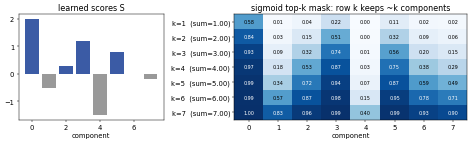

In [5]:
import math, time, json, random, gc, os, threading
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
os.makedirs("/kaggle/working/figs", exist_ok=True)
plt.rcParams.update({"figure.dpi": 44, "font.size": 11})
def show(fig, name):
    fig.savefig(f"/kaggle/working/figs/{name}.png", dpi=130, bbox_inches="tight")   # full-res copy on disk
    plt.show()

# ----------------------------------------------------------------------------------------------
# Sigmoid top-k (Wijk et al. 2025; paper Definition 2; repo sigmoid_topk.py)
#   mask_i = sigmoid((s_i - tau) / T), with tau chosen by bisection so that sum_i mask_i = k.
#   (The paper writes sigma(S + c_k) with T = 1 and c_k = -tau.)
# ----------------------------------------------------------------------------------------------
class SigmoidTopK(torch.autograd.Function):
    @staticmethod
    def forward(ctx, s, k, T, n_iters):
        N = s.numel()
        # Bracket for tau. At lo every sigmoid is >= sigma(a), at hi every sigmoid is <= sigma(-a).
        # a = log N + 10 guarantees f(lo) > k > f(hi) for any 1 <= k <= N-1.
        # (The repo uses a = 10. With N = 2.3M neurons and all scores at 0 that bracket cannot
        #  reach k < N*sigma(-10) ~ 104, so tiny-k masks sum to ~104 early in training.)
        a = T * (math.log(N) + 10.0)
        lo, hi = s.min() - a, s.max() + a
        with torch.no_grad():
            for _ in range(n_iters):                        # f(tau) = sum sigmoid((s-tau)/T) is decreasing in tau
                mid = (lo + hi) / 2
                too_many = torch.sigmoid((s - mid) / T).sum() > k
                lo = torch.where(too_many, mid, lo)         # sum too big -> raise tau
                hi = torch.where(too_many, hi, mid)
        tau = (lo + hi) / 2
        m = torch.sigmoid((s - tau) / T)
        ctx.save_for_backward(m); ctx.T = T
        return m

    @staticmethod
    def backward(ctx, g):
        # Implicit differentiation of the constraint sum_i sigma((s_i - tau)/T) = k  (paper eq. 11):
        #   sp_i = m_i (1 - m_i)  (sigmoid slope)
        #   dtau/ds_j = sp_j / sum_i sp_i
        #   dL/ds_j   = (sp_j / T) * (g_j - sum_i g_i sp_i / sum_i sp_i)
        (m,) = ctx.saved_tensors
        sp = m * (1 - m)
        gbar = (g * sp).sum() / sp.sum().clamp_min(1e-12)
        return (sp / ctx.T) * (g - gbar), None, None, None

def sigmoid_topk(s, k, T=0.5, n_iters=50):
    return SigmoidTopK.apply(s, float(k), T, n_iters)

# ---- test 1: the mask really sums to k ------------------------------------------------------
torch.manual_seed(0)
for N in [8, 1057, 2_293_760]:
    s = torch.randn(N, dtype=torch.float64) * (0 if N > 10_000 else 1)   # the big one: all zeros, like step 0
    for k in [1, 3.5, N / 2, N - 1]:
        m = sigmoid_topk(s, k, n_iters=80)
        assert abs(m.sum().item() - k) < 1e-6 * max(1, k), (N, k, m.sum().item())
print("test 1  sum(mask) == k for N in {8, 1057, 2.3M} and k in {1, 3.5, N/2, N-1}:  OK")

# ---- test 2: analytic gradient == finite differences ----------------------------------------
s = torch.randn(12, dtype=torch.float64, requires_grad=True); w = torch.randn(12, dtype=torch.float64); k = 4.0
(sigmoid_topk(s, k, n_iters=200) * w).sum().backward()
fd = torch.zeros(12, dtype=torch.float64)
for j in range(12):
    e = torch.zeros(12, dtype=torch.float64); e[j] = 1e-6
    fd[j] = ((sigmoid_topk(s.detach() + e, k, n_iters=200) * w).sum() - (sigmoid_topk(s.detach() - e, k, n_iters=200) * w).sum()) / 2e-6
print(f"test 2  max |analytic - finite-diff| = {(s.grad - fd).abs().max().item():.2e}   (gradient scale {fd.abs().max().item():.2f})")
print(f"        gradient sums to {s.grad.sum().item():.1e}: shifting ALL scores by c changes nothing (paper A.4, 'not complete')")

# ---- test 3: Matryoshka nesting -- every mask entry rises monotonically with k -----------------
s = torch.randn(200, dtype=torch.float64)
M = torch.stack([sigmoid_topk(s, k, n_iters=80) for k in np.linspace(1, 199, 400)])
print(f"test 3  min over (k, i) of mask_k+1[i] - mask_k[i] = {(M[1:] - M[:-1]).min().item():.2e}  (>= 0 means nested)")

# ---- picture: 8 scores, masks for k = 1..7 (paper Figure 1, panel 2) --------------------------
s8 = torch.tensor([2.0, -0.5, 0.3, 1.2, -1.5, 0.8, 0.0, -0.2], dtype=torch.float64)
M8 = torch.stack([sigmoid_topk(s8, k, T=0.5, n_iters=80) for k in range(1, 8)]).numpy()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios": [1, 1.6]})
ax[0].bar(range(8), s8.numpy(), color=["#3b5ba5" if v > 0 else "#999" for v in s8]); ax[0].set_title("learned scores S"); ax[0].set_xlabel("component")
im = ax[1].imshow(M8, cmap="Blues", vmin=0, vmax=1, aspect="auto")
for i in range(7):
    for j in range(8): ax[1].text(j, i, f"{M8[i, j]:.2f}", ha="center", va="center", fontsize=8, color="k" if M8[i, j] < .6 else "w")
ax[1].set_yticks(range(7)); ax[1].set_yticklabels([f"k={k}  (sum={M8[k-1].sum():.2f})" for k in range(1, 8)])
ax[1].set_title("sigmoid top-k mask: row k keeps ~k components"); ax[1].set_xlabel("component")
plt.tight_layout(); show(fig, "sigmoid_topk")


---
# Part 2. A toy where we know the right answer

Before the 8B model, here is a 16-component "model" whose ground truth we can compute exactly. There are only `2^16 = 65,536` subsets, so we can **brute-force the best circuit of every size** and compare each method to it.

Every component has base value 1 and source value 0, so the keep-mask `α` *is* the component's value:

`LD(α) = 5·tanh(3·α_A + 2.4·α_B) + 3·α_C + 0.6·(α_D1 + … + α_D5) + 0.02·(α_Z1 + … + α_Z8) − 4`

* **A and B are backups for each other.** Both feed one saturating unit, and either one alone almost fills it (`5·tanh(3) = 4.98`). Keep A and B is worth only `+0.02` more.
* **C** is a strong plain effect (3). **D1–D5** are weak plain effects (0.6 each). **Z1–Z8** are almost noise.

What goes wrong for gradients: at the clean point the tanh is **saturated** (`tanh(5.4)`), so `∂LD/∂α_A ≈ 0`. **I×G sees A and B as useless**, even though swapping both out costs 5 logits. This is the classic failure of attribution patching (it also happens with attention softmax and LayerNorm).

I×G        ranking: C > D1 > D2 > D3 > D4 > D5 > Z1 > Z2 ...
IG (m=10)  ranking: C > A > B > D1 > D2 > D3 > D4 > D5 ...
MAttr      ranking: C > A > D1 > D2 > D3 > D4 > D5 > B ...


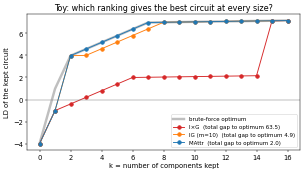

In [11]:
toy_names = ["A", "B", "C"] + [f"D{i}" for i in range(1, 6)] + [f"Z{i}" for i in range(1, 9)]
NT = len(toy_names)
def toy_LD(a):
    return 5 * torch.tanh(3 * a[..., 0] + 2.4 * a[..., 1]) + 3 * a[..., 2] + 0.6 * a[..., 3:8].sum(-1) + 0.02 * a[..., 8:].sum(-1) - 4

# brute force: all 65,536 subsets at once, best LD for each size k
subsets = ((torch.arange(2 ** NT)[:, None] >> torch.arange(NT)) & 1).double()
vals, sizes = toy_LD(subsets), subsets.sum(1).long()
optimal = [vals[sizes == k].max().item() for k in range(NT + 1)]

def toy_grad(t):                      # dLD/dalpha at alpha = t * 1
    a = torch.full((NT,), float(t), dtype=torch.float64, requires_grad=True); toy_LD(a).backward(); return a.grad
toy_scores = {
    "I×G": toy_grad(1.0),
    "IG (m=10)": sum(toy_grad((i + .5) / 10) for i in range(10)) / 10,
}
def toy_mattr(steps=1500, lr=0.05, seed=0, T=0.5):
    torch.manual_seed(seed)
    S = torch.zeros(NT, dtype=torch.float64, requires_grad=True); opt = torch.optim.Adam([S], lr=lr)
    for _ in range(steps):
        k = 1 + (NT - 1) * torch.rand(1).item()
        loss = -toy_LD(sigmoid_topk(S, k, T))
        opt.zero_grad(); loss.backward(); opt.step()
    return S.detach()
toy_scores["MAttr"] = toy_mattr()

def toy_curve(sc):
    o, out = sc.argsort(descending=True), []
    for k in range(NT + 1):
        m = torch.zeros(NT, dtype=torch.float64); m[o[:k]] = 1; out.append(toy_LD(m).item())
    return out
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(NT + 1), optimal, "k-", lw=4, alpha=.25, label="brute-force optimum")
for (nm, sc), c in zip(toy_scores.items(), ["#d62728", "#ff7f0e", "#1f77b4"]):
    cv = toy_curve(sc)
    ax.plot(range(NT + 1), cv, "o-", color=c, label=f"{nm}  (total gap to optimum {sum(o - v for o, v in zip(optimal, cv)):.1f})")
    print(f"{nm:10s} ranking: {' > '.join(toy_names[i] for i in sc.argsort(descending=True)[:8])} ...")
ax.axhline(0, color="gray", lw=.8); ax.set_xlabel("k = number of components kept"); ax.set_ylabel("LD of the kept circuit")
ax.set_title("Toy: which ranking gives the best circuit at every size?"); ax.legend(fontsize=9); show(fig, "toy")


**What the toy shows**
* **I×G** ranks A and B *below the noise*, because the gradient is taken at the saturated clean point. Its 2- to 14-component circuits are far from optimal.
* **IG** averages the gradient along the whole path, so it sees A and B. But it gives the backups *equal* credit and keeps B at rank 3, where B adds nothing once A is in.
* **MAttr keeps learning.** Once A's mask is near 1, B's gradient goes to zero (the tanh is full), so MAttr pushes B **down to 8th**, below all five D's. It is optimal at every size except `k = 1`. At `k = 1` it keeps C (3) instead of A (4.98), because early training, with soft masks, credits C's plain effect. Switching to the log-uniform `k` schedule did not change that in our runs. So "MAttr beats IG" here means "MAttr handles redundancy", not "MAttr is optimal".

---
# Part 3. Theorem 1: the first MAttr step *is* a weighted Integrated Gradients

At `S = 0` every score is equal, so sigmoid top-k gives every component the same mask value `α_H = k/N =: t`. The gradient through sigmoid top-k (paper eq. 15) is

`∂ℓ/∂s_H = (1/T) · t(1−t) · ( IxG_H(t) − mean_j IxG_j(t) )`, with `IxG_H(t) = ∂ℓ/∂α_H` at `α = t·1`.

`k` is uniform, so `t` is (almost) uniform on (0,1). Averaging over it:

`E_k[−∂ℓ/∂s_H] = (1/T)·(1/6) · ( IG^ρ_H − mean_j IG^ρ_j ) + O(1/N)`, where `IG^ρ_H = ∫₀¹ ρ(t)·∂LD/∂α_H(t·1) dt` and `ρ(t) = 6t(1−t)`.

So one SGD step of MAttr from zero **is** Integrated Gradients along the mask path, with the path weighted by a Beta(2,2) bump that ignores both ends (the saturated clean end and the fully swapped end), and centred. The check below runs the *real* autograd path (our `SigmoidTopK.backward`) and compares it with the formula.

In [12]:
T = 0.5
# LEFT side: the actual expected first-step direction, E_k[-dloss/dS] at S = 0, through the real SigmoidTopK backward.
# k ~ Uniform(1, N-1) -> averaged on a dense uniform k grid (midpoint rule, 4000 points).
ks = 1 + (NT - 2) * (np.arange(4000) + 0.5) / 4000
lhs = torch.zeros(NT, dtype=torch.float64)
for k in ks:
    S = torch.zeros(NT, dtype=torch.float64, requires_grad=True)
    (-toy_LD(sigmoid_topk(S, k, T, n_iters=100))).backward()
    lhs += -S.grad / len(ks)

# RIGHT side, exact form (paper eq. 23): (1/T) * N/(N-2) * integral_{1/N}^{1-1/N} t(1-t) (IxG(t) - mean IxG(t)) dt
# (k uniform on [1, N-1] has density 1/(N-2); the paper writes 1/(N-1), which only matters at O(1/N))
ts = np.linspace(1 / NT, 1 - 1 / NT, 4001); tm = (ts[1:] + ts[:-1]) / 2; dt = ts[1] - ts[0]
G = torch.stack([toy_grad(t) for t in tm])                         # [steps, N] gradient of LD along the mask path
cen = G - G.mean(1, keepdim=True)
rhs_exact = (torch.tensor(tm * (1 - tm))[:, None] * cen).sum(0) * dt * NT / (NT - 2) / T
# RIGHT side, the theorem's large-N form: (1/T)(1/6)(IG^rho - mean IG^rho), rho = 6 t (1-t) on the full [0,1]
ts2 = (np.arange(4000) + 0.5) / 4000
G2 = torch.stack([toy_grad(t) for t in ts2]); cen2 = G2 - G2.mean(1, keepdim=True)
IG_rho = (torch.tensor(6 * ts2 * (1 - ts2))[:, None] * cen2).mean(0)
rhs_thm = IG_rho / 6 / T

print(f"{'comp':5s} {'E[first step]':>14s} {'exact integral':>15s} {'Theorem 1':>10s}")
for i in range(8): print(f"{toy_names[i]:5s} {lhs[i].item():14.5f} {rhs_exact[i].item():15.5f} {rhs_thm[i].item():10.5f}")
print(f"\nmax |first step - exact integral|  = {(lhs - rhs_exact).abs().max().item():.1e}   (identical up to quadrature)")
print(f"max |first step - Theorem 1|       = {(lhs - rhs_thm).abs().max().item():.3f}   (the O(1/N) end-effect, N = {NT})")
print(f"Spearman(first step, IG^rho) = {np.corrcoef(lhs.argsort().argsort(), rhs_thm.argsort().argsort())[0,1]:.3f}")
print(f"the first step sums to {lhs.sum().item():.1e}: centred, as the theorem says")


comp   E[first step]  exact integral  Theorem 1
A            0.36712         0.36712    0.36551
B            0.25208         0.25208    0.25422
C            0.90910         0.90910    0.80907
D1           0.01535         0.01535    0.00907
D2           0.01535         0.01535    0.00907
D3           0.01535         0.01535    0.00907
D4           0.01535         0.01535    0.00907
D5           0.01535         0.01535    0.00907

max |first step - exact integral|  = 1.7e-14   (identical up to quadrature)
max |first step - Theorem 1|       = 0.100   (the O(1/N) end-effect, N = 16)
Spearman(first step, IG^rho) = 1.000
the first step sums to -8.9e-16: centred, as the theorem says


---
# Part 4. The real thing: Llama-3.1-8B

**Memory math.** 8.03 billion weights × 2 bytes (fp16) = 16.1 GB. One T4 has 15 GB, so the model is split across both: embeddings + layers 0 to 15 on GPU 0, layers 16 to 31 + the output head on GPU 1. Activations hop across once per forward pass.

**Why fp16 and not bf16:** the T4 has no bf16 tensor cores. bf16 would be emulated and about 4× slower.

**We never train the model.** All 8 billion weights stay frozen (`requires_grad=False`). The only trainable thing is one score per component. We still backpropagate *through* the frozen model to reach those scores.

In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from huggingface_hub import snapshot_download
os.environ["HF_HOME"] = "/content/hf"
path = snapshot_download("unsloth/Meta-Llama-3.1-8B", allow_patterns=["*.json", "*.safetensors"])   # already cached
dmap = {"model.embed_tokens": 0, "model.rotary_emb": 0, "model.norm": 1, "lm_head": 1}
dmap.update({f"model.layers.{i}": (0 if i < 16 else 1) for i in range(32)})
t0 = time.time()
tok = AutoTokenizer.from_pretrained(path)
model = AutoModelForCausalLM.from_pretrained(path, dtype=torch.float16, device_map=dmap)
model.eval(); model.requires_grad_(False)
cfg = model.config
L, H, D, NI, DM = cfg.num_hidden_layers, cfg.num_attention_heads, cfg.hidden_size // cfg.num_attention_heads, cfg.intermediate_size, cfg.hidden_size
print(f"loaded in {time.time()-t0:.0f}s | {sum(p.numel() for p in model.parameters())/1e9:.2f}B params | layers={L} heads={H} head_dim={D} mlp_neurons={NI} d_model={DM}")
for g in range(2): print(f"cuda:{g}: {torch.cuda.memory_allocated(g)/2**30:.2f} GiB allocated")
print("attn impl:", model.config._attn_implementation)


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

loaded in 39s | 8.03B params | layers=32 heads=32 head_dim=128 mlp_neurons=14336 d_model=4096
cuda:0: 7.48 GiB allocated
cuda:1: 7.48 GiB allocated
attn impl: sdpa


In [7]:
# ---- Can Llama-3.1-8B add? Test all 10,000 prompts "a+b=" with a, b in 1..100 ----------------
prompts = [(a, b) for a in range(1, 101) for b in range(1, 101)]
texts = [f"{a}+{b}=" for a, b in prompts]
ids = tok(texts, return_tensors="pt").input_ids                    # BOS + 4 tokens, e.g. [<bos>, '57', '+', '38', '=']
assert ids.shape[1] == 5, ids.shape
ans = torch.tensor([tok.encode(str(a + b), add_special_tokens=False)[0] for a, b in prompts])
assert all(len(tok.encode(str(s), add_special_tokens=False)) == 1 for s in range(2, 201))   # every sum 2..200 is ONE token
print("tokens of '57+38=':", tok.convert_ids_to_tokens(tok("57+38=").input_ids), "-> answer token", repr(tok.decode(ans[prompts.index((57, 38))])))

@torch.no_grad()
def last_logits(input_ids, bs=500):
    out = []
    for i in range(0, len(input_ids), bs):
        out.append(model(input_ids[i:i + bs].to("cuda:0")).logits[:, -1].float().cpu())
    return torch.cat(out)
t0 = time.time()
LG = last_logits(ids)
pred = LG.argmax(-1)
correct = (pred == ans)
print(f"accuracy {correct.float().mean():.1%} over 10,000 problems ({time.time()-t0:.0f}s)")
for a, b in [(57, 38), (99, 99), (12, 71), (3, 4), (100, 100)]:
    i = prompts.index((a, b)); print(f"   {a}+{b}= -> {tok.decode(pred[i])!r} {'OK' if correct[i] else 'WRONG'}")

# ---- counterfactual pairs: base and source both answered correctly, different answers -----------
g = torch.Generator().manual_seed(0)
ok = correct.nonzero().squeeze(1)
ok = ok[torch.randperm(len(ok), generator=g)]
n_test_pool = len(ok) // 7
pools = {"test": ok[:n_test_pool], "train": ok[n_test_pool:]}          # disjoint BASE prompts for train/test
def make_pairs(pool, n):
    b = pool[torch.randint(len(pool), (n,), generator=g)]
    s = pool[torch.randint(len(pool), (n,), generator=g)]
    keep = ans[b] != ans[s]
    return {"b": ids[b[keep]], "s": ids[s[keep]], "yb": ans[b[keep]], "ys": ans[s[keep]]}
TRAIN = make_pairs(pools["train"], 8000)
TEST = make_pairs(pools["test"], 400)
print(f"pairs: train {len(TRAIN['yb'])}, test {len(TEST['yb'])}")
ld = lambda lg, yb, ys: lg.gather(1, yb[:, None].to(lg.device)).squeeze(1) - lg.gather(1, ys[:, None].to(lg.device)).squeeze(1)
lb, ls = last_logits(TEST["b"]), last_logits(TEST["s"])
print(f"test clean   LD = logit(base ans) - logit(source ans): mean {ld(lb, TEST['yb'], TEST['ys']).mean():+.2f}")
print(f"test source  LD on the source prompt itself:           mean {ld(ls, TEST['yb'], TEST['ys']).mean():+.2f}")


tokens of '57+38=': ['<|begin_of_text|>', '57', '+', '38', '='] -> answer token '95'
accuracy 94.6% over 10,000 problems (47s)
   57+38= -> '95' OK
   99+99= -> '198' OK
   12+71= -> '83' OK
   3+4= -> '7' OK
   100+100= -> '200' OK
pairs: train 7947, test 399
test clean   LD = logit(base ans) - logit(source ans): mean +6.57
test source  LD on the source prompt itself:           mean -6.65


### 4.1 Where exactly we intervene
Each Llama layer adds two things to the residual stream: an attention output and an MLP output. We hook the **inputs of the two output projections**, because there each unit has a clean meaning:
* `o_proj` input, shape `[batch, pos, 32 heads × 128]` → split into **32 heads**. Head `h` of layer `l` is one component `a{l}.h{h}`.
* `down_proj` input, shape `[batch, pos, 14,336]` → **one MLP block** `m{l}` (node level) or **14,336 neurons** (neuron level, Part 5).
* The token embeddings → one **input** node.

That makes `1 + 32×32 + 32 = 1,057` components at node level, the same graph MIB uses for Llama (paper Fig. 20 says "1057 nodes").

**Soft interchange intervention (paper Def. 1):** a hooked value becomes `h_src + α·(h_base − h_src)`. So `α = 1` keeps the base value, `α = 0` swaps in the source value, and anything in between is a blend. At node level one `α` covers a component at every token position.

We compute that blend in fp32, so the gradient with respect to `α` (a sum over thousands of activations) is summed in fp32, not fp16. We also scale the loss by 1024 before the backward pass so small fp16 gradients do not round to zero, and divide it back out afterwards.

**Two sanity checks that must hold exactly:** mask = all ones → the clean base run. Mask = all zeros → *every* addend of the residual stream is the source's, so we get the source run.

In [8]:
class Patcher:
    """Soft interchange interventions on a HF Llama (mirrors repo models/llama.py).
    Flat mask layout:
      node   : [input] [a0.h0 .. a31.h31] [m0 .. m31]              total 1 + L*H + L = 1057
      neuron : [(layer, pos, neuron)] for layer 0..31, pos 0..P-1   total L*P*14336
    self.mask = None -> hooks do nothing.  self.record = True -> hooks store their input in self.src."""
    def __init__(self, model, substrate, P=5):
        self.substrate, self.P = substrate, P
        self.total = 1 + L * H + L if substrate == "node" else L * P * NI
        self.mask, self.record, self.src, self.hooks = None, False, {}, []
        self.hooks.append(model.model.embed_tokens.register_forward_hook(self._emb))
        for l, layer in enumerate(model.model.layers):
            self.hooks.append(layer.self_attn.o_proj.register_forward_pre_hook(self._attn(l)))
            self.hooks.append(layer.mlp.down_proj.register_forward_pre_hook(self._mlp(l)))

    @staticmethod
    def mix(x, src, m):   # x = base activation, src = source activation, m = keep-weight in [0,1]
        return (src.float() + m.to(x.device) * (x.float() - src.float())).to(x.dtype)

    def _emb(self, mod, inp, out):
        if self.record: self.src["emb"] = out.detach(); return
        if self.mask is None or self.substrate != "node": return
        return self.mix(out, self.src["emb"], self.mask[0])

    def _attn(self, l):
        def hook(mod, args):
            x = args[0]
            if self.record: self.src[("a", l)] = x.detach(); return
            if self.mask is None or self.substrate != "node": return
            B, P, _ = x.shape
            m = self.mask[1 + l * H: 1 + (l + 1) * H].view(1, 1, H, 1)
            return (self.mix(x.view(B, P, H, D), self.src[("a", l)].view(B, P, H, D), m).view(B, P, H * D),)
        return hook

    def _mlp(self, l):
        def hook(mod, args):
            x = args[0]
            if self.record: self.src[("m", l)] = x.detach(); return
            if self.mask is None: return
            if self.substrate == "node": m = self.mask[1 + L * H + l]
            else:                        m = self.mask[l * self.P * NI:(l + 1) * self.P * NI].view(1, self.P, NI)
            return (self.mix(x, self.src[("m", l)], m),)
        return hook

    @torch.no_grad()
    def cache_source(self, s_ids):
        self.record, m = True, self.mask
        model(s_ids.to("cuda:0")); self.record, self.mask = False, m

    def run(self, b_ids, mask):
        """Forward the base prompts with `mask` applied. Returns last-token logits (float32, cuda:1)."""
        self.mask = mask
        out = model(b_ids.to("cuda:0")).logits[:, -1].float()
        self.mask = None
        return out

    def names(self):
        if self.substrate == "node":
            return ["input"] + [f"a{l}.h{h}" for l in range(L) for h in range(H)] + [f"m{l}" for l in range(L)]
        return None
    def remove(self):
        for h in self.hooks: h.remove()

# ---- sanity checks -------------------------------------------------------------------------------
b, s = TEST["b"][:16], TEST["s"][:16]
yb, ys = TEST["yb"][:16], TEST["ys"][:16]
with torch.no_grad():
    clean, source = model(b.to("cuda:0")).logits[:, -1].float(), model(s.to("cuda:0")).logits[:, -1].float()
for sub in ["node", "neuron"]:
    pt = Patcher(model, sub)
    pt.cache_source(s)
    with torch.no_grad():
        ones = pt.run(b, torch.ones(pt.total, device="cuda:0"))
        zeros = pt.run(b, torch.zeros(pt.total, device="cuda:0"))
    msg = (f"|mask=0 - source run| = {(zeros-source).abs().max():.3f}" if sub == "node" else
           f"mask=0 (every MLP neuron patched, attention untouched) gives LD {ld(zeros, yb, ys).mean():+.2f} vs clean {ld(clean, yb, ys).mean():+.2f}")
    print(f"{sub:6s} total={pt.total:>9,} |mask=1 - clean| = {(ones-clean).abs().max():.3f}   {msg}   (logit scale ~{clean.abs().max():.0f})")
    pt.remove()


node   total=    1,057 |mask=1 - clean| = 0.000   |mask=0 - source run| = 0.000   (logit scale ~15)
neuron total=2,293,760 |mask=1 - clean| = 0.000   mask=0 (every MLP neuron patched, attention untouched) gives LD -6.95 vs clean +6.74   (logit scale ~15)


### 4.2 How a ranking is scored (paper §4, eqs. 4, 5, 8, 9)
Given a ranking, keep the top-`k` components (a **hard** 0/1 mask), swap all others to the source, and measure on **held-out** test pairs:
* **Faithfulness** `Faith(k) = (LD(k) − LD(0)) / (LD(all) − LD(0))`: 0 means "as bad as the fully swapped run", 1 means "as good as the clean run". It *can* exceed 1.
* **IIA** (interchange intervention accuracy) = fraction of pairs where the model still prefers the base answer.

Each is evaluated at `k = ⌊p·N⌋` for `p ∈ {0.1%, 0.2%, 0.5%, 1%, 2%, 5%, 10%, 20%, 50%, 100%}`.
* **CPR** = area under Faith vs. `p`, linear axis. Higher is better. It is dominated by the large-circuit end.
* **Compactness** = area under IIA vs. `log k`, normalised to [0,1]. It rewards *small* circuits that already get the answer right.

### 4.3 The MAttr training loop (paper Algorithm 1)
Each step: sample a batch of pairs, cache the source activations, draw `k`, build `α = sigmoid_topk(S, k)`, run the base prompt under the soft intervention, compute `loss = −mean LD`, backprop into `S`, take one Adam step. That is the whole algorithm.

### 4.4 Baselines, all using the same hooks
* **I×G** (attribution patching): `∂LD/∂α` at `α = 1`. By the chain rule this is exactly `Σ (h_base − h_src)·∂LD/∂h`, the classic formula.
* **IG** (m = 10): the average of `∂LD/∂α` along the straight line `α = t·1`, `t ∈ (0,1)`, in mask space. This is the IG that Theorem 1 talks about.
* **Activation patching** (the causal gold standard, 1,057 extra forward passes): the drop in LD when *only* component `j` is swapped.
* **Random** ranking.

In [9]:
GRID = [.001, .002, .005, .01, .02, .05, .1, .2, .5, 1.0]
SCALE = 1024.0      # static loss scale for the fp16 backward

@torch.no_grad()
def mean_ld(pt, data, mask, bs=100):
    out = []
    for i in range(0, len(data["yb"]), bs):
        pt.cache_source(data["s"][i:i + bs])
        out.append(ld(pt.run(data["b"][i:i + bs], mask), data["yb"][i:i + bs], data["ys"][i:i + bs]).cpu())
    return torch.cat(out)

def evaluate(pt, scores, data=None, grid=GRID):
    data = data or TEST
    N = pt.total
    order = scores.to("cuda:0").argsort(descending=True)
    ld0 = mean_ld(pt, data, torch.zeros(N, device="cuda:0")).mean().item()
    ldN = mean_ld(pt, data, torch.ones(N, device="cuda:0")).mean().item()
    ks, faith, iia = [], [], []
    for p in grid:
        k = max(1, int(p * N)); m = torch.zeros(N, device="cuda:0"); m[order[:k]] = 1
        l = mean_ld(pt, data, m)
        ks.append(k); faith.append((l.mean().item() - ld0) / (ldN - ld0)); iia.append((l > 0).float().mean().item())
    cpr = sum((grid[i + 1] - grid[i]) * (faith[i] + faith[i + 1]) / 2 for i in range(len(grid) - 1))
    lk = np.log(ks)
    compact = sum((lk[i + 1] - lk[i]) * (iia[i] + iia[i + 1]) / 2 for i in range(len(ks) - 1)) / (lk[-1] - lk[0])
    return {"k": ks, "faith": faith, "iia": iia, "CPR": cpr, "Compactness": compact}

def sample_k(N, sched):
    u = torch.rand(1).item()
    return 1 + (N - 1) * u if sched == "uniform" else math.exp(math.log(N) * u)

class MAttr:
    """Paper Algorithm 1. Resumable: call .train(n) repeatedly."""
    def __init__(self, pt, data, lr=0.05, eps=1e-8, bs=8, sched="uniform", T=0.5, seed=0, optim="adam"):
        torch.manual_seed(seed)
        self.pt, self.data, self.bs, self.sched, self.T = pt, data, bs, sched, T
        self.S = torch.zeros(pt.total, device="cuda:0", requires_grad=True)
        self.opt = (torch.optim.Adam([self.S], lr=lr, eps=eps) if optim == "adam" else torch.optim.SGD([self.S], lr=lr))
        self.step, self.log, self.skipped, self.t = 0, [], 0, 0.0

    def train(self, n, log_every=100, quiet=False):
        n_data = len(self.data["yb"])
        for _ in range(n):
            t0 = time.time()
            idx = torch.randint(n_data, (self.bs,))
            self.pt.cache_source(self.data["s"][idx])
            k = sample_k(self.pt.total, self.sched)
            m = sigmoid_topk(self.S, k, self.T)
            lg = self.pt.run(self.data["b"][idx], m)
            loss = -ld(lg, self.data["yb"][idx], self.data["ys"][idx]).mean()
            self.opt.zero_grad(set_to_none=True)
            (loss * SCALE).backward()
            self.S.grad /= SCALE
            if not torch.isfinite(self.S.grad).all():          # fp16 overflow guard (like GradScaler)
                self.skipped += 1; continue
            self.opt.step()
            self.step += 1; self.t += time.time() - t0
            self.log.append((self.step, k, loss.item()))
            if not quiet and (self.step % log_every == 0 or self.step == 1):
                recent = np.mean([x[2] for x in self.log[-log_every:]])
                print(f"step {self.step:5d}  k={k:9.1f}  loss={loss.item():+.3f}  (avg last {log_every}: {recent:+.3f})  "
                      f"|S|max={self.S.abs().max().item():.2f}  {self.step/self.t:.1f} step/s  skipped={self.skipped}")
        return self

def grad_attr(pt, data, n, bs, t_values):
    """Mean dLD/dmask over n examples, averaged over mask points alpha = t*1 for t in t_values.
       t_values=[1.0] -> I×G.   t_values=[(i+.5)/m] -> IG along the mask path (m steps)."""
    acc = torch.zeros(pt.total, device="cuda:0", dtype=torch.float64); cnt = 0
    for i in range(0, n, bs):
        b, s, yb, ys = (data[x][i:i + bs] for x in ("b", "s", "yb", "ys"))
        pt.cache_source(s)
        for t in t_values:
            m = torch.full((pt.total,), t, device="cuda:0", requires_grad=True)
            (ld(pt.run(b, m), yb, ys).mean() * SCALE).backward()
            acc += m.grad.double() / SCALE; cnt += 1
    return (acc / cnt).float()

@torch.no_grad()
def activation_patching(pt, data, n=64):
    """Causal baseline: LD drop when ONLY component j is swapped to the source (node level)."""
    b, s, yb, ys = (data[x][:n] for x in ("b", "s", "yb", "ys"))
    pt.cache_source(s)
    base = ld(pt.run(b, torch.ones(pt.total, device="cuda:0")), yb, ys).mean()
    out = torch.zeros(pt.total)
    for j in range(pt.total):
        m = torch.ones(pt.total, device="cuda:0"); m[j] = 0
        out[j] = base - ld(pt.run(b, m), yb, ys).mean()
    return out

# ---- timing probe: one node-level MAttr step ------------------------------------------------------
PT = Patcher(model, "node")
probe = MAttr(PT, TRAIN, bs=8).train(5, quiet=True)
print(f"node level: {probe.step/probe.t:.2f} steps/s at batch 8  ->  500 steps ~ {500/(probe.step/probe.t)/60:.1f} min")
print("peak mem GiB:", [round(torch.cuda.max_memory_allocated(g)/2**30, 2) for g in range(2)])


node level: 2.71 steps/s at batch 8  ->  500 steps ~ 3.1 min
peak mem GiB: [8.32, 8.26]


### 4.5 Train MAttr on 1,057 components
The paper's node-level recipe: Adam, lr 0.05, ε = 1e-8, uniform `k`, T = 0.5, 500 steps. The paper uses batch 1. We use batch 8 because it costs the same wall-clock time here (the T4 is limited by reading weights, not by arithmetic), and it averages out example noise.

In [10]:
torch.manual_seed(0)
node_run = MAttr(PT, TRAIN, lr=0.05, eps=1e-8, bs=8, sched="uniform", T=0.5, seed=0).train(500, log_every=100)
S_node = node_run.S.detach().clone()
names = PT.names()
top = S_node.argsort(descending=True)[:15].tolist()
print("\nMAttr top-15 components:", ", ".join(names[i] for i in top))


step     1  k=    482.1  loss=+6.867  (avg last 100: +6.867)  |S|max=0.05  3.2 step/s  skipped=0
step   100  k=    687.3  loss=-15.432  (avg last 100: -5.303)  |S|max=4.18  3.5 step/s  skipped=0
step   200  k=    513.8  loss=-21.493  (avg last 100: -15.314)  |S|max=5.80  3.5 step/s  skipped=0
step   300  k=    912.4  loss=-21.666  (avg last 100: -18.996)  |S|max=6.33  3.5 step/s  skipped=1
step   400  k=    966.0  loss=-15.989  (avg last 100: -17.548)  |S|max=7.01  3.5 step/s  skipped=2

MAttr top-15 components: m29, m26, a28.h19, a15.h13, m27, m24, m25, m15, m28, m23, a28.h18, m16, m20, m17, a16.h21


In [13]:
# ---- baselines on the same 1,057 components ----------------------------------------------------------
t0 = time.time(); S_ixg = grad_attr(PT, TRAIN, n=1000, bs=50, t_values=[1.0]);                         t_ixg = time.time() - t0
t0 = time.time(); S_ig = grad_attr(PT, TRAIN, n=400, bs=50, t_values=[(i + .5) / 10 for i in range(10)]); t_ig = time.time() - t0
t0 = time.time(); S_ap = activation_patching(PT, TRAIN, n=64);                                          t_ap = time.time() - t0
S_rand = torch.randn(PT.total, generator=torch.Generator().manual_seed(1))
print(f"I×G {t_ixg:.0f}s   IG {t_ig:.0f}s   activation patching {t_ap:.0f}s   (MAttr training took {node_run.t:.0f}s)")

node_methods = {"MAttr": S_node, "Activation patching": S_ap, "IG (m=10)": S_ig, "I×G": S_ixg, "Random": S_rand}
node_eval = {nm: evaluate(PT, sc) for nm, sc in node_methods.items()}
print(f"\n{'method':22s} {'CPR':>6s} {'Compact':>8s}   Faith at k = " + " ".join(f"{k:>5d}" for k in node_eval['MAttr']['k']))
for nm, r in node_eval.items():
    print(f"{nm:22s} {r['CPR']:6.2f} {r['Compactness']:8.3f}   " + " " * 13 + " ".join(f"{f:5.2f}" for f in r["faith"]))


I×G 15s   IG 45s   activation patching 375s   (MAttr training took 142s)

method                    CPR  Compact   Faith at k =     1     2     5    10    21    52   105   211   528  1057
MAttr                    1.73    0.496                 0.00  0.00  0.00  0.00  0.02  1.18  1.53  1.98  2.31  1.00
Activation patching      1.20    0.495                 0.00  0.00  0.00  0.01  0.05  1.12  1.30  1.32  1.36  1.00
IG (m=10)                1.18    0.497                 0.00  0.00  0.00  0.01  0.18  1.19  1.23  1.25  1.33  1.00
I×G                      0.25    0.050                 0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00
Random                   0.25    0.050                 0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00


In [15]:
for nm, sc in node_methods.items():
    print(f"{nm:22s} finite={torch.isfinite(sc).all().item()}  max|s|={sc.abs().max().item():.3g}  nan={torch.isnan(sc).sum().item()}")


MAttr                  finite=True  max|s|=7.52  nan=0
Activation patching    finite=True  max|s|=13.7  nan=0
IG (m=10)              finite=True  max|s|=1.57  nan=0
I×G                    finite=True  max|s|=1.81  nan=0
Random                 finite=True  max|s|=3.95  nan=0


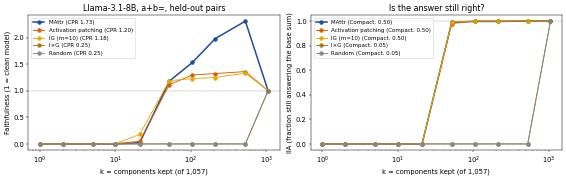

method                  input  a15.h13  a16.h21   (ranks out of 1,057)   top-8
MAttr                      21        4       15                          m29, m26, a28.h19, a15.h13, m27, m24, m25, m15
Activation patching         1        5        3                          input, m0, a16.h21, m18, a15.h13, m15, m17, m12
IG (m=10)                   1        5        4                          input, m0, m18, a16.h21, a15.h13, m12, m13, m15
I×G                      1049        9       14                          m29, m24, m27, m23, m25, m18, a28.h19, m28
Random                    984      618      543                          a25.h10, a31.h18, a18.h22, a31.h19, a31.h10, a25.h24, a19.h24, a30.h11


In [16]:
colors = {"MAttr": "#1f4e9c", "Activation patching": "#d95f02", "IG (m=10)": "#e6ab02", "I×G": "#a6761d", "Random": "#888888"}
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for nm, r in node_eval.items():
    ax[0].plot(r["k"], r["faith"], "o-", color=colors[nm], label=f"{nm} (CPR {r['CPR']:.2f})", lw=2.5 if nm == "MAttr" else 1.5)
    ax[1].plot(r["k"], r["iia"], "o-", color=colors[nm], label=f"{nm} (Compact. {r['Compactness']:.2f})", lw=2.5 if nm == "MAttr" else 1.5)
for a, yl in zip(ax, ["Faithfulness (1 = clean model)", "IIA (fraction still answering the base sum)"]):
    a.set_xscale("log"); a.set_xlabel("k = components kept (of 1,057)"); a.set_ylabel(yl); a.axhline(1, color="k", lw=.6, ls=":"); a.legend(fontsize=9)
ax[0].set_title("Llama-3.1-8B, a+b=, held-out pairs"); ax[1].set_title("Is the answer still right?")
plt.tight_layout(); show(fig, "node_curves")

# ---- the known arithmetic heads (Nikankin et al. 2025): a15.h13 and a16.h21, and the input node ----------
print(f"{'method':22s} {'input':>6s} {'a15.h13':>8s} {'a16.h21':>8s}   (ranks out of 1,057)   top-8")
for nm, sc in node_methods.items():
    order = sc.argsort(descending=True).tolist(); rk = {names[i]: r + 1 for r, i in enumerate(order)}
    print(f"{nm:22s} {rk['input']:6d} {rk['a15.h13']:8d} {rk['a16.h21']:8d}   {'':22s} {', '.join(names[i] for i in order[:8])}")


### 4.6 What the node-level run shows

| method | CPR ↑ | Compactness ↑ | cost on 2×T4 |
|---|---|---|---|
| **MAttr** (500 steps) | **1.73** | 0.496 | 142 s |
| Activation patching (1,057 forward passes) | 1.20 | 0.495 | 375 s |
| IG (m = 10) | 1.18 | 0.497 | 45 s |
| I×G | 0.25 | 0.050 | 15 s |
| Random | 0.25 | 0.050 | 0 s |

Paper, MIB node level, averaged over 12 task–model pairs: MAttr 2.06, IG 1.29, causal patching 1.14, I×G 0.46. **Same ordering.**

1. **MAttr has the highest CPR, 44% above activation patching**, the one-at-a-time causal gold standard, at a third of its cost.
2. **Where that lead comes from.** At `k = 528` MAttr's circuit has faithfulness **2.31**: the half-model circuit gives a *larger* logit difference than the full model. It keeps the components that push toward `95` and swaps out the ones that push against it. The paper itself flags this as a weakness of CPR (logit difference is unbounded) and adds **Compactness**, where MAttr, activation patching and IG are tied at about 0.50.
3. **I×G collapses to random because it ranks the input embedding 1,049th of 1,057.** Swapping the input changes every token, which is a huge change, and a gradient at one point badly underestimates it. Every kept head and MLP recomputes from its (swapped) inputs, so no circuit works without the input. It is the same lesson as the toy in Part 2, now at 8B scale.
4. **The arithmetic heads.** MAttr puts `a15.h13` at #4 and `a16.h21` at #15. These are the heads Nikankin et al. (2025) found by hand. To be fair, activation patching and IG also rank both in their top 5, so this *confirms* the known heads rather than being unique to MAttr.
5. **A visible weakness.** MAttr ranks the input node only #21, so its circuits of 10 or fewer components are useless (faithfulness 0), while IG and activation patching put the input first. Uniform `k` spends only about 2% of training steps at `k < 21`. This is exactly why the paper offers a **log-uniform `k`** schedule for the small-circuit end.

### 4.7 Controlled experiment: one knob at a time
Two questions, each changing exactly one thing from the headline run:
* **Seed noise.** Same recipe, seeds 1 and 2. Are CPR and the head ranks stable?
* **`k` schedule.** Log-uniform `k` (a draw of `k` from 1–10 is as likely as one from 100–1,000) spends far more steps on small circuits. Does it pull the input node up and fix the dead zone at `k ≤ 10`? The paper (§4, Result 2) says log-`k` trades some CPR for better Compactness.

In [37]:
variants = {"uniform k, seed 0 (headline)": S_node}
for label, sched, seed in [("uniform k, seed 1", "uniform", 1), ("uniform k, seed 2", "uniform", 2), ("log-uniform k, seed 0", "log", 0)]:
    torch.manual_seed(seed)
    variants[label] = MAttr(PT, TRAIN, lr=0.05, eps=1e-8, bs=8, sched=sched, seed=seed).train(500, quiet=True).S.detach().clone()
print(f"{'variant':30s} {'CPR':>5s} {'Compact':>8s} {'input':>6s} {'a15.h13':>8s} {'a16.h21':>8s}   faith at k=1,2,5,10,21")
variant_eval = {}
for label, sc in variants.items():
    r = variant_eval[label] = evaluate(PT, sc)
    order = sc.argsort(descending=True).tolist(); rk = {names[i]: j + 1 for j, i in enumerate(order)}
    print(f"{label:30s} {r['CPR']:5.2f} {r['Compactness']:8.3f} {rk['input']:6d} {rk['a15.h13']:8d} {rk['a16.h21']:8d}   " + " ".join(f"{f:.2f}" for f in r["faith"][:5]))


variant                          CPR  Compact  input  a15.h13  a16.h21   faith at k=1,2,5,10,21
uniform k, seed 0 (headline)    1.73    0.496     21        4       15   0.00 0.00 0.00 0.00 0.02
uniform k, seed 1               1.74    0.496     13        1        2   0.00 0.00 0.00 0.00 0.15
uniform k, seed 2               1.73    0.497     15        7       11   0.00 0.00 0.00 0.00 0.06
log-uniform k, seed 0           1.68    0.497      8        1        2   0.00 0.00 0.00 0.01 0.18


**Result of the controlled experiment**
* **Seeds:** CPR is 1.73, 1.74 and 1.73 and Compactness 0.496–0.497, so the *curve* is very stable. Individual ranks wobble: `a15.h13` lands at #4, #1, #7 and `a16.h21` at #15, #2, #11. Read "which component is #1" with a grain of salt. Read "which components are in the top 15" with confidence.
* **Log-uniform `k`:** CPR drops a little (1.68), which is the trade-off the paper describes. The input node climbs from #21 to #8, and the two known arithmetic heads come out at **#1 and #2**. More training steps at small `k` sharpens the head of the ranking, which is exactly the claim of paper §4 Result 2.
* Circuits of 10 or fewer components are still near 0 faithfulness under every variant. On this task, the answer needs the input plus a couple of dozen components before any circuit works.

---
# Part 5. Down to single neurons: 2,293,760 units

Now every (layer, token position, MLP neuron) triple is its own component: `32 × 5 × 14,336 = 2,293,760` scores. That is too many for activation patching (2.3 million forward passes).

**Ground truth from another paper.** Feucht et al. (2026), *"Arithmetic in the Wild: Llama uses base-10 addition to reason about cyclic concepts"*, found a set of **28 layer-18 MLP neurons** in this exact model that write the answer of `a+b=` (they searched layer 18 using DAS subspaces). MAttr is never told about layer 18 or about these neurons. **Where does it rank them among 458,752 distinct neurons?**

**The Adam ε trap (paper §A.3 and §D.3).** Adam's step is `m̂/(√v̂ + ε)`. With millions of scores, most per-step gradients are tiny, far below the default `ε = 1e-8`. Then `√v̂ ≫ ε` and the step becomes `≈ sign(gradient)`: every unit that got *any* gradient moves by the full learning rate, however small its real effect was. The score turns into a **count of steps**, and the *size* of each neuron's effect is thrown away. Raising ε above the typical gradient size puts magnitude back in (large-ε Adam behaves like SGD with momentum). The paper's fix for fine-grained bases is **ε = 1e-2**. We run **both** as a controlled experiment. The only difference between the two runs is ε.

In [17]:
import urllib.request
FEUCHT = json.loads(urllib.request.urlopen(
    "https://raw.githubusercontent.com/aryamanarora/matryoshka-attribution/main/src/matryoshka_attribution/data/arith_wild_l18_neurons.json").read())
KNOWN = {t: set(v) for t, v in FEUCHT["neurons"].items()}
print({t: len(v) for t, v in KNOWN.items()}, "| layer", FEUCHT["layer"])

class BG:
    """Run a long job in a background thread so the notebook stays responsive; poll with .status()."""
    def __init__(self, fn):
        self.done, self.err, self.out = False, None, None
        self.th = threading.Thread(target=self._go, args=(fn,), daemon=True); self.th.start()
    def _go(self, fn):
        try: self.out = fn()
        except Exception:
            import traceback; self.err = traceback.format_exc()
        self.done = True

def neuron_view(scores, P):
    """[L*P*NI] -> [L, P, NI]"""
    return scores.view(L, P, NI)

def neuron_ranks(scores, P):
    """Rank of each of the 458,752 distinct (layer, neuron) pairs, using its best-scoring position (repo convention)."""
    best = neuron_view(scores.float().cpu(), P).max(1).values.flatten()        # [L*NI]
    order = best.argsort(descending=True)
    rank = torch.empty_like(order); rank[order] = torch.arange(len(order))
    return rank.view(L, NI), best.view(L, NI)

def known_report(scores, P, task, label):
    rank, _ = neuron_ranks(scores, P)
    r = sorted(rank[FEUCHT["layer"], n].item() for n in KNOWN[task])
    hits = {K: sum(x < K for x in r) for K in [10, 100, 1000, 10000]}
    print(f"{label:28s} known {task} neurons in top-10: {hits[10]:2d}  top-100: {hits[100]:2d}  top-1k: {hits[1000]:2d}  top-10k: {hits[10000]:2d}"
          f"  / {len(r)}   (median rank {int(np.median(r)):,} of {L*NI:,})")
    return r

PTN = Patcher(model, "neuron", P=5)
probe = MAttr(PTN, TRAIN, bs=8).train(5, quiet=True)
print(f"neuron level: {probe.step/probe.t:.2f} steps/s at batch 8 -> 5000 steps ~ {5000/(probe.step/probe.t)/60:.0f} min")
del probe


{'months': 16, 'weekdays': 15, 'hours': 26, 'addition': 28} | layer 18
neuron level: 3.34 steps/s at batch 8 -> 5000 steps ~ 25 min


In [18]:
# ---- three neuron-level MAttr runs + gradient baselines, chained in one background thread (~1.5 h) ------
# Only the optimiser differs between the runs:
#   Adam eps=1e-2 : the paper's recipe for granular bases (lr 0.05, uniform k)
#   Adam eps=1e-8 : the default eps (the "sign of the gradient" regime)
#   SGD           : lr 1.0, log-uniform k (paper Table B.1 "+log k, +SGD"; the repo's best arm on neuron recall)
NEURON_STEPS = 5000
RUNS = {
    "MAttr Adam ε=1e-2": MAttr(PTN, TRAIN, lr=0.05, eps=1e-2, bs=8, sched="uniform", seed=0),
    "MAttr Adam ε=1e-8": MAttr(PTN, TRAIN, lr=0.05, eps=1e-8, bs=8, sched="uniform", seed=0),
    "MAttr SGD":         MAttr(PTN, TRAIN, lr=1.0, bs=8, sched="log", seed=0, optim="sgd"),
}
NEURON_BASE = {}
def neuron_job():
    for nm, r in RUNS.items():
        r.train(NEURON_STEPS, quiet=True)
    NEURON_BASE["I×G"] = grad_attr(PTN, TRAIN, n=1000, bs=50, t_values=[1.0])
    NEURON_BASE["IG (m=10)"] = grad_attr(PTN, TRAIN, n=400, bs=50, t_values=[(i + .5) / 10 for i in range(10)])
job = BG(neuron_job)


In [25]:
# Mid-run numerical fix (applied at step ~1,800 of the first run). As MAttr sharpens, the masked model is
# driven to logit differences of ~90, and the fp16 backward started overflowing at loss scale 1024
# (6% of steps skipped). The scale is divided back out before the optimizer step, so lowering it
# changes nothing mathematically; it only moves the fp16 range. The training loop reads SCALE each step.
SCALE = 64.0
print("SCALE =", SCALE)


SCALE = 64.0


In [29]:
# ---- progress (re-run any time) ------------------------------------------------------------------------
for nm, r in RUNS.items():
    avg = np.mean([x[2] for x in r.log[-200:]]) if r.log else float("nan")
    print(f"{nm:20s} step {r.step:5d}/{NEURON_STEPS}  loss(avg last 200) {avg:+7.2f}  {r.step/max(r.t,1e-9):.2f} steps/s  skipped {r.skipped}")
print("baselines done:", list(NEURON_BASE), "| job done:", job.done, "| error:", job.err, "|", datetime.datetime.now().strftime("%H:%M:%S"))


MAttr Adam ε=1e-2    step  3717/5000  loss(avg last 200)  -94.96  3.46 steps/s  skipped 126
MAttr Adam ε=1e-8    step     0/5000  loss(avg last 200)    +nan  0.00 steps/s  skipped 0
MAttr SGD            step     0/5000  loss(avg last 200)    +nan  0.00 steps/s  skipped 0
baselines done: [] | job done: False | error: None | 05:51:36


In [33]:
# bounded wait (never longer than ~18 min per call): returns when the condition holds or the timeout hits
def wait_until(cond, timeout=1080, every=15):
    t0 = time.time()
    while time.time() - t0 < timeout and not cond():
        time.sleep(every)
    return cond()
print("job finished:", wait_until(lambda: job.done), "|", {nm: r.step for nm, r in RUNS.items()},
      "| baselines:", list(NEURON_BASE), "| err:", job.err)


job finished: True | {'MAttr Adam ε=1e-2': 4874, 'MAttr Adam ε=1e-8': 4990, 'MAttr SGD': 5000} | baselines: ['I×G', 'IG (m=10)'] | err: None


---
# Part 6. A different task: months

Feucht et al.'s central claim is that Llama **reuses its base-10 addition neurons** for cyclic concepts. For example, `Q: What month is three months after July?` is answered with the same layer-18 neurons that do `a+b=`. Their months set has 16 neurons, and 15 of them are also in the addition set.

We train MAttr **from scratch on months prompts only**, with no addition data and no hint about layer 18. Two questions:
1. Does it find Feucht's months neurons?
2. Do its top neurons overlap with the ones MAttr found on **addition**?

method                 CPR  Compact   Faith at k =    2,293    4,587   11,468   22,937   45,875  114,688  229,376  458,752 1,146,880 2,293,760
MAttr Adam ε=1e-2     5.20    0.968                    0.60     2.01     4.51     5.53     6.31     6.92     6.63     6.51     6.70     1.00
MAttr Adam ε=1e-8     6.29    0.904                    0.22     0.80     4.21     5.38     6.25     7.07     7.81     8.23     8.36     1.00
MAttr SGD             1.12    0.948                    0.82     0.95     1.28     1.23     1.18     1.16     1.16     1.16     1.17     1.00
I×G                   1.03    0.587                    0.10     0.18     0.31     0.43     0.57     0.81     0.98     1.08     1.10     1.00
IG (m=10)             1.06    0.978                    0.87     1.03     1.09     1.08     1.04     1.03     1.05     1.08     1.09     1.00
Random                0.26    0.050                    0.00     0.00     0.00     0.00     0.00    -0.00    -0.00     0.00     0.01     1.00


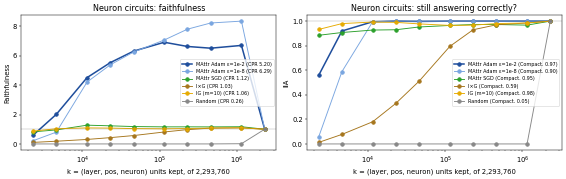

In [36]:
# ---- faithfulness of neuron circuits on held-out pairs (same metrics as Part 4, now over 2,293,760 units) ----
neuron_eval = {nm: evaluate(PTN, sc) for nm, sc in S_neuron.items()}
print(f"{'method':20s} {'CPR':>5s} {'Compact':>8s}   Faith at k = " + " ".join(f"{k:>8,d}" for k in neuron_eval['Random']['k']))
for nm, r in neuron_eval.items():
    print(f"{nm:20s} {r['CPR']:5.2f} {r['Compactness']:8.3f}   {'':13s}" + " ".join(f"{f:8.2f}" for f in r["faith"]))
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for nm, r in neuron_eval.items():
    ax[0].plot(r["k"], r["faith"], "o-", color=ncol[nm], lw=2.5 if "1e-2" in nm else 1.5, label=f"{nm} (CPR {r['CPR']:.2f})")
    ax[1].plot(r["k"], r["iia"], "o-", color=ncol[nm], lw=2.5 if "1e-2" in nm else 1.5, label=f"{nm} (Compact. {r['Compactness']:.2f})")
for a, yl in zip(ax, ["Faithfulness", "IIA"]):
    a.set_xscale("log"); a.set_xlabel("k = (layer, pos, neuron) units kept, of 2,293,760"); a.set_ylabel(yl); a.axhline(1, color="k", lw=.6, ls=":"); a.legend(fontsize=8)
ax[0].set_title("Neuron circuits: faithfulness"); ax[1].set_title("Neuron circuits: still answering correctly?")
plt.tight_layout(); show(fig, "neuron_curves")


MAttr Adam ε=1e-2            known addition neurons in top-10:  0  top-100:  3  top-1k: 22  top-10k: 28  / 28   (median rank 276 of 458,752)
MAttr Adam ε=1e-8            known addition neurons in top-10:  0  top-100:  1  top-1k: 11  top-10k: 27  / 28   (median rank 1,538 of 458,752)
MAttr SGD                    known addition neurons in top-10:  1  top-100:  6  top-1k: 27  top-10k: 28  / 28   (median rank 186 of 458,752)
I×G                          known addition neurons in top-10:  0  top-100:  8  top-1k: 25  top-10k: 27  / 28   (median rank 193 of 458,752)
IG (m=10)                    known addition neurons in top-10:  3  top-100: 15  top-1k: 28  top-10k: 28  / 28   (median rank 89 of 458,752)
Random                       known addition neurons in top-10:  0  top-100:  0  top-1k:  1  top-10k:  1  / 28   (median rank 235,923 of 458,752)


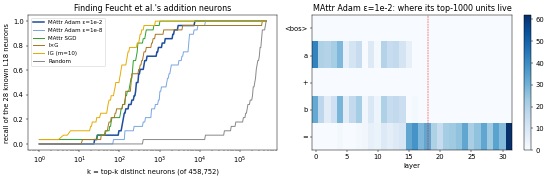

top-1000 units by layer (top 6): [(0, 74), (31, 62), (4, 58), (11, 47), (13, 40), (16, 39)] | by position: [('=', 540), ('a', 237), ('b', 223)]
MAttr Adam ε=1e-2  top-10 units: L15/=/N12769, L15/=/N130, L15/=/N6456, L12/b/N6649, L15/=/N2670, L17/=/N4767, L11/b/N8001, L17/=/N1975, L15/=/N12465, L12/b/N788
MAttr SGD          top-10 units: L18/=/N1712, L21/=/N9178, L15/=/N13664, L20/=/N9747, L9/b/N9344, L4/b/N3465, L26/=/N2322, L17/=/N1165, L17/=/N13232, L4/b/N2551
IG (m=10)          top-10 units: L18/=/N1712, L15/=/N130, L15/=/N7446, L18/=/N11096, L19/=/N6862, L18/=/N1448, L20/=/N11837, L20/=/N11129, L21/=/N9178, L19/=/N5338


In [35]:
# ---- Where do the known addition neurons land? ---------------------------------------------------------
from collections import Counter
S_neuron = {nm: r.S.detach().clone() for nm, r in RUNS.items()}
S_neuron.update(NEURON_BASE)
S_neuron["Random"] = torch.randn(PTN.total, generator=torch.Generator().manual_seed(1))
ranks = {nm: known_report(sc, 5, "addition", nm) for nm, sc in S_neuron.items()}

# recall curve: fraction of the 28 known neurons inside each method's top-k distinct neurons
ncol = {"MAttr Adam ε=1e-2": "#1f4e9c", "MAttr Adam ε=1e-8": "#7aa6e0", "MAttr SGD": "#2ca02c", "IG (m=10)": "#e6ab02", "I×G": "#a6761d", "Random": "#888888"}
kk = np.unique(np.logspace(0, np.log10(L * NI), 300).astype(int))
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for nm, r in ranks.items():
    ax[0].plot(kk, [(np.array(r) < k).mean() for k in kk], color=ncol[nm], lw=2.5 if "1e-2" in nm else 1.6, label=nm)
ax[0].set_xscale("log"); ax[0].set_xlabel("k = top-k distinct neurons (of 458,752)"); ax[0].set_ylabel("recall of the 28 known L18 neurons")
ax[0].set_title("Finding Feucht et al.'s addition neurons"); ax[0].legend(fontsize=9)

# where does MAttr's attention go? count of its top-1000 units by (layer, position)
best_nm = "MAttr Adam ε=1e-2"
top_units = S_neuron[best_nm].argsort(descending=True)[:1000].cpu()
lay, pos = top_units // (5 * NI), (top_units // NI) % 5
Hm = np.zeros((5, L)); np.add.at(Hm, (pos.numpy(), lay.numpy()), 1)
im = ax[1].imshow(Hm, aspect="auto", cmap="Blues"); plt.colorbar(im, ax=ax[1])
ax[1].set_yticks(range(5)); ax[1].set_yticklabels(["<bos>", "a", "+", "b", "="]); ax[1].set_xlabel("layer")
ax[1].set_title(f"{best_nm}: where its top-1000 units live"); ax[1].axvline(18, color="r", lw=.8, ls="--")
plt.tight_layout(); show(fig, "neuron_recall")
print("top-1000 units by layer (top 6):", Counter(lay.tolist()).most_common(6), "| by position:", Counter([['<bos>','a','+','b','='][p] for p in pos.tolist()]).most_common())
for nm in ["MAttr Adam ε=1e-2", "MAttr SGD", "IG (m=10)"]:
    tu = S_neuron[nm].argsort(descending=True)[:10].cpu()
    print(f"{nm:18s} top-10 units:", ", ".join(f"L{int(u // (5 * NI))}/{['<bos>','a','+','b','='][int((u // NI) % 5)]}/N{int(u % NI)}" for u in tu))


### 5.1 What the neuron-level runs show

**Finding the 28 hand-found neurons** (rank among 458,752 distinct neurons, each neuron scored at its best position):

| method | in top 10 | top 100 | top 1,000 | median rank |
|---|---|---|---|---|
| IG (m = 10) | 3 | 15 | **28 / 28** | **89** |
| MAttr SGD (log `k`) | 1 | 6 | 27 | 186 |
| I×G | 0 | 8 | 25 | 193 |
| MAttr Adam ε = 1e-2 | 0 | 3 | 22 | 276 |
| MAttr Adam ε = 1e-8 | 0 | 1 | 11 | 1,538 |
| Random | 0 | 0 | 1 | 235,923 |

**Faithfulness of the neuron circuits** (held-out pairs):

| method | CPR | Compactness | faithfulness with 0.1% of units kept |
|---|---|---|---|
| MAttr Adam ε = 1e-2 | 5.20 | 0.968 | 0.60 |
| MAttr Adam ε = 1e-8 | 6.29 | 0.904 | 0.22 |
| MAttr SGD | 1.12 | 0.948 | 0.82 |
| IG (m = 10) | 1.06 | **0.978** | **0.87** |
| I×G | 1.03 | 0.587 | 0.10 |

What this means, plainly:
1. **Every method is hundreds of times better than chance** at finding Feucht et al.'s neurons, from a search over the whole model with no hint about layer 18. The best methods put all 28 in their top 0.2%.
2. **The Adam ε effect reproduces.** Changing only ε from 1e-8 to 1e-2 improves the median rank of the known neurons 5.6× (1,538 → 276) and Compactness (0.904 → 0.968). The ε = 1e-8 run gets the *higher* CPR, which is the same pattern as the paper's Fig. 8 (Llama-3 / MLP: CPR 5.38 vs 4.33, Compactness 0.33 vs 0.43). Magnitude-blind "sign" updates find circuits that overshoot a lot but are less compact.
3. **The repo's recall claim does not reproduce here.** The official code notes that MAttr + SGD finds a published neuron in its top 5 more often than IG does. In our single run (one task, one seed, batch 8, fp16), **IG ranks the published neurons best**. Two caveats. First, those neurons were *selected* by overlap with a linear DAS subspace, which may favour gradient-style methods. Second, MAttr is not trained to find them. It is trained to keep the answer.
4. **CPR vs Compactness disagree, and why.** MAttr-Adam's circuits, with 5% of units kept, drive the logit difference up to **7× past the full model** (faithfulness 6.9): they keep the neurons that push toward `95` and swap out the ones pushing against it. That inflates CPR (5.2 vs about 1 for IG). On the accuracy-based Compactness, and at the tiniest circuits, **IG is as good or better**. The paper names exactly this weakness of CPR as its reason for adding Compactness.
5. **Where MAttr looks.** 54% of MAttr's top-1,000 units sit at the `=` token and the rest at the two operands, never at `<bos>` or `+`. Its top-10 are mostly **layer 15** neurons at `=`. SGD and IG both put **L18 / N1712**, one of Feucht's neurons, at #1.

In [38]:
raw = json.loads(urllib.request.urlopen(
    "https://raw.githubusercontent.com/goodfire-ai/arithmetic-wild/main/datasets/Llama-3.1-8B/months/filtered_dataset.json").read())
mb = [d["raw_input"] for d in raw["input"]]; mbo = [d["raw_output"] for d in raw["input"]]
ms = [c[0]["raw_input"] for c in raw["counterfactual_inputs"]]; mso = [c[0]["raw_output"] for c in raw["counterfactual_inputs"]]
print(repr(mb[0]), "->", repr(mbo[0]), "| source:", repr(ms[0]), "->", repr(mso[0]))
lens_b = [len(tok(x).input_ids) for x in mb]; lens_s = [len(tok(x).input_ids) for x in ms]
from collections import Counter
PM = Counter(lens_b).most_common(1)[0][0]
keep = [i for i in range(len(mb)) if lens_b[i] == PM and lens_s[i] == PM
        and tok.encode(mbo[i], add_special_tokens=False)[0] != tok.encode(mso[i], add_special_tokens=False)[0]]
print(f"{len(mb)} pairs; modal length {PM} tokens; {len(keep)} pairs with both prompts at that length and different answers")
print("tokens:", tok.convert_ids_to_tokens(tok(mb[keep[0]]).input_ids))
MB = tok([mb[i] for i in keep], return_tensors="pt").input_ids; MS = tok([ms[i] for i in keep], return_tensors="pt").input_ids
MYB = torch.tensor([tok.encode(mbo[i], add_special_tokens=False)[0] for i in keep]); MYS = torch.tensor([tok.encode(mso[i], add_special_tokens=False)[0] for i in keep])
lgb, lgs = last_logits(MB), last_logits(MS)
okm = (lgb.argmax(-1) == MYB) & (lgs.argmax(-1) == MYS)
print(f"our fp16 model answers both prompts correctly on {okm.float().mean():.1%} of those pairs")
idx = okm.nonzero().squeeze(1); idx = idx[torch.randperm(len(idx), generator=torch.Generator().manual_seed(0))]
nte = min(300, len(idx) // 5)
M_TEST = {"b": MB[idx[:nte]], "s": MS[idx[:nte]], "yb": MYB[idx[:nte]], "ys": MYS[idx[:nte]]}
M_TRAIN = {"b": MB[idx[nte:]], "s": MS[idx[nte:]], "yb": MYB[idx[nte:]], "ys": MYS[idx[nte:]]}
print(f"months pairs: train {len(M_TRAIN['yb'])}, test {len(M_TEST['yb'])}; clean test LD {ld(lgb[idx[:nte]], M_TEST['yb'], M_TEST['ys']).mean():+.2f}")


'Q: What month is two months after September?\nA:' -> ' November' | source: 'Q: What month is three months after July?\nA:' -> ' October'
4096 pairs; modal length 13 tokens; 3100 pairs with both prompts at that length and different answers
tokens: ['<|begin_of_text|>', 'Q', ':', 'ĠWhat', 'Ġmonth', 'Ġis', 'Ġtwo', 'Ġmonths', 'Ġafter', 'ĠSeptember', '?Ċ', 'A', ':']
our fp16 model answers both prompts correctly on 97.5% of those pairs
months pairs: train 2724, test 300; clean test LD +5.13


In [39]:
# ---- MAttr on months, neuron level: 32 layers x PM positions x 14,336 neurons (+ IG as the baseline) -----
PTM = Patcher(model, "neuron", P=PM)
print(f"months substrate: {PTM.total:,} units")
month_run = MAttr(PTM, M_TRAIN, lr=0.05, eps=1e-2, bs=8, sched="uniform", seed=0)
MONTH_BASE = {}
def month_job_fn():
    month_run.train(NEURON_STEPS, quiet=True)
    MONTH_BASE["IG (m=10)"] = grad_attr(PTM, M_TRAIN, n=400, bs=50, t_values=[(i + .5) / 10 for i in range(10)])
month_job = BG(month_job_fn)


months substrate: 5,963,776 units


In [41]:
print("finished:", wait_until(lambda: month_job.done))
avg = np.mean([x[2] for x in month_run.log[-200:]]) if month_run.log else float("nan")
print(f"months run: step {month_run.step}/{NEURON_STEPS}  loss(avg last 200) {avg:+.2f}  {month_run.step/max(month_run.t,1e-9):.2f} steps/s | IG done: {'IG (m=10)' in MONTH_BASE} | err {month_job.err}")


finished: True
months run: step 5000/5000  loss(avg last 200) -91.37  2.47 steps/s | IG done: True | err None


MAttr trained on MONTHS      known months neurons in top-10:  2  top-100:  8  top-1k: 15  top-10k: 16  / 16   (median rank 140 of 458,752)
IG on MONTHS                 known months neurons in top-10:  3  top-100: 10  top-1k: 16  top-10k: 16  / 16   (median rank 44 of 458,752)
Random                       known months neurons in top-10:  0  top-100:  0  top-1k:  0  top-10k:  0  / 16   (median rank 217,117 of 458,752)

    K   MAttr: shared add∩months   IG: shared add∩months   chance
   10                          0                       2    0.000
   25                          0                       6    0.001
   50                          2                      15    0.005
  100                          8                      34    0.022
  500                        139                     184    0.545

MAttr-on-months top 15 neurons   (A = in Feucht addition set, M = in Feucht months set)
   L22 N 3927      best position 12 ':'            rank in the ADDITION run 102,548
   L 2 N 1

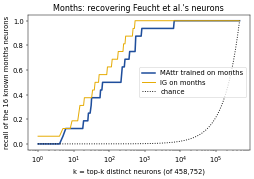

In [42]:
S_month = month_run.S.detach().clone()
S_month_ig = MONTH_BASE["IG (m=10)"]
r_month = known_report(S_month, PM, "months", "MAttr trained on MONTHS")
r_month_ig = known_report(S_month_ig, PM, "months", "IG on MONTHS")
_ = known_report(torch.randn(PTM.total, generator=torch.Generator().manual_seed(1)), PM, "months", "Random")

# ---- overlap between the neurons picked on addition and on months (independent runs, different datasets) ----
def top_set(scores, P, K):
    rank, _ = neuron_ranks(scores, P)
    return set(map(tuple, (rank < K).nonzero().tolist()))
print(f"\n{'K':>5s} {'MAttr: shared add∩months':>26s} {'IG: shared add∩months':>23s} {'chance':>8s}")
for K in [10, 25, 50, 100, 500]:
    m_sh = len(top_set(S_neuron[best_nm], 5, K) & top_set(S_month, PM, K))
    i_sh = len(top_set(S_neuron["IG (m=10)"], 5, K) & top_set(S_month_ig, PM, K))
    print(f"{K:5d} {m_sh:26d} {i_sh:23d} {K * K / (L * NI):8.3f}")

rank_a, _ = neuron_ranks(S_neuron[best_nm], 5)
rank_m, _ = neuron_ranks(S_month, PM)
tok_m = tok.convert_ids_to_tokens(M_TRAIN["b"][0])
order_m = rank_m.flatten().argsort()[:15]
print("\nMAttr-on-months top 15 neurons   (A = in Feucht addition set, M = in Feucht months set)")
for i in order_m.tolist():
    l, n = divmod(i, NI)
    tags = ("A" if l == 18 and n in KNOWN["addition"] else " ") + ("M" if l == 18 and n in KNOWN["months"] else " ")
    pos = neuron_view(S_month.cpu(), PM)[l, :, n].argmax().item()
    print(f"   L{l:2d} N{n:5d} {tags}   best position {pos:2d} {tok_m[pos]!r:12s}   rank in the ADDITION run {rank_a[l, n].item():>7,}")

kk = np.unique(np.logspace(0, np.log10(L * NI), 300).astype(int))
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(kk, [(np.array(r_month) < k).mean() for k in kk], color="#1f4e9c", lw=2.5, label="MAttr trained on months")
ax.plot(kk, [(np.array(r_month_ig) < k).mean() for k in kk], color="#e6ab02", lw=1.6, label="IG on months")
ax.plot(kk, kk / (L * NI), "k:", label="chance")
ax.set_xscale("log"); ax.set_xlabel("k = top-k distinct neurons (of 458,752)"); ax.set_ylabel("recall of the 16 known months neurons")
ax.set_title("Months: recovering Feucht et al.'s neurons"); ax.legend(); show(fig, "months_recall")


### 6.1 What the months run shows

**Feucht's 16 months neurons**, ranked among 458,752 by attribution trained on *months prompts only*:

| method | top 10 | top 100 | top 1,000 | median rank |
|---|---|---|---|---|
| MAttr (Adam ε = 1e-2) | 2 | 8 | 15 / 16 | 140 |
| IG (m = 10) | 3 | 10 | 16 / 16 | 44 |
| Random | 0 | 0 | 0 | 217,117 |

**Do addition and months use the same neurons?** Here is the overlap between the top-K neurons found on addition and the top-K found on months, from two independent runs on two different datasets:

| K | MAttr: shared | IG: shared | expected by chance |
|---|---|---|---|
| 100 | 8 | 34 | 0.02 |
| 500 | 139 | 184 | 0.55 |

1. **Feucht et al.'s central claim shows up without supervision.** MAttr trained only on "What month is N months after X?" puts `L18/N1712` and `L18/N10099` at #5 and #6. Both are in Feucht's addition *and* months sets. The 500 neurons MAttr picks for months share 139 with the 500 it picks for addition, **about 250 times chance**. Llama really does reuse its addition machinery for calendar arithmetic, and an attribution method trained on a loss finds that on its own.
2. **Where the months circuit reads out.** 14 of MAttr's top-15 months neurons act at the final `:` token (the answer position), in layers 18 to 29. Layer 18 appears through the two shared neurons above.
3. **Same caveat as Part 5.** IG again ranks the published neurons slightly better (median 44 vs 140) and shows even more addition/months overlap. Here MAttr confirms the finding. It does not beat the gradient baseline at it.

---
# Summary: what reproduced, what did not

| paper claim | our result on Llama-3.1-8B, 2 × T4 | verdict |
|---|---|---|
| Sigmoid top-k gives a differentiable mask that keeps exactly `k`, nested across `k` | Sum = k to 1e-6, gradient = finite differences to 1e-10, monotone in `k` | ✅ |
| Theorem 1: the first MAttr step is centred, Beta(2,2)-weighted IG | Matches the exact integral to 1.7e-14. The O(1/N) edge term is visible at N = 16 | ✅ |
| MAttr beats causal patching, IG and I×G on node-level CPR | 1.73 vs 1.20 / 1.18 / 0.25 | ✅ (ordering) |
| MAttr's node CPR lead partly reflects overshoot. Compactness is the fairer small-circuit metric | Faithfulness 2.31 at k = 528. Compactness ties across MAttr, patching and IG (0.50) | ✅ |
| Known arithmetic heads `a15.h13`, `a16.h21` rank high | #4 and #15 (uniform k), #1 and #2 (log k). Patching and IG also find them | ✅, not unique to MAttr |
| Log-uniform `k` trades a little CPR for a sharper head of the ranking | CPR 1.73 → 1.68, known heads → #1 and #2, input node #21 → #8 | ✅ |
| Adam ε matters at fine-grained bases (ε = 1e-2 ≫ 1e-8) | Median rank of known neurons 276 vs 1,538. Compactness 0.968 vs 0.904. ε = 1e-8 has higher CPR, as in the paper's Fig. 8 | ✅ |
| MAttr (SGD or large-ε Adam) matches or beats IG at recovering Feucht's neurons | IG is best in our run (median 89 vs 186 for SGD, 276 for Adam) | ❌ in this single run |
| Cross-task: addition and months share neurons | MAttr months top-500 ∩ addition top-500 = 139 (≈250× chance). Two shared L18 neurons in the months top 6 | ✅ |
| Parameter attribution with RL: restoring 1% of weights removes refusal | Not run here | — |

**Honest scope:** one task family, one seed per neuron-level arm, batch 8, fp16 on T4. The evaluation code is our own re-implementation of the paper's metrics, not MIB's harness. Numbers are comparable to the paper in ordering and pattern, not in absolute value.